<a href="https://colab.research.google.com/github/emilyshabinaw/Final-Project-/blob/main/ShabinawFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Predicting Gastrointestinal Diseases**

### **Introduction**

Gastrointestinal diseases affect millions of people worldwide, including myself, as I was diagnosed with Celiac Disease as recent as 2 years ago. Many Gastrointestinal diseases present with the same symptoms making accurate diagnoses challenging and time consuming. Machine learning is able to assist in identifying disease patterns and improving accuracy in diagnoses. This project analyzes a gastrointestinal disease dataset from kaggle containing patient symptoms and medical features to predict disease classifications using supervised Machine Learning Algorithms.

The primary goal of this analysis is to determine whether machine learning models can accurately classify gastrointestinal diseases based on patient data. This project addresses the following key questions:

1. Which machine learning model performs best for this
classification task?
2. What features or symptoms are most important in predicting disease outcomes?

This project starts by exploring the data provided, then prepares the data for MLM's, and finally, analyzes the data using MLM's, specifically using Logistic Regression, KNN, Decision Trees, and Random Forest.




### **Uploading The Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
import pandas as pd
url = "https://raw.githubusercontent.com/emilyshabinaw/Final-Project-/main/gastrointestinal_disease_dataset%20(1).csv"

df = pd.read_csv(url)
df.head()

,Age,Gender,BMI,Body_Weight,Obesity_Status,Ethnicity,Family_History,Genetic_Markers,Microbiome_Index,Autoimmune_Disorders,...,Rectal_Bleeding,Appetite_Loss,Weight_Loss,Bowel_Habits,Bowel_Movement_Frequency,NSAID_Use,Antibiotic_Use,PPI_Use,Medications,Disease_Class
0,9,Female,19.1,44.1,Normal,Black,0,9,0.25,1,...,1,1,1,Irregular,5,0,0,0,1,Unexplained weight loss
1,78,Male,38.2,121.0,Obese,White,1,10,0.27,1,...,0,1,0,Normal,4,0,1,1,1,Blood in stool
2,20,Male,34.2,79.0,Obese,Black,1,6,0.83,0,...,0,0,0,Frequent,0,1,0,0,0,Nausea or vomiting
3,73,Female,30.8,68.4,Obese,Asian,0,1,0.67,0,...,0,1,0,Infrequent,2,0,1,0,1,Nausea or vomiting
4,58,Male,26.4,66.7,Overweight,White,0,1,0.84,1,...,0,1,0,Normal,4,0,0,1,1,Unexplained weight loss


### **Exploratory Data Analysis**

**Describes features of the data set, the structure, and to understand  the distribution of each numerical feature**

In [ ]:
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
                 Age           BMI   Body_Weight  Family_History  \
count  30560.000000  30560.000000  30560.000000    30560.000000   
mean      47.220124     27.987513     72.600435        0.499738   
std       24.923513      6.958877     24.121179        0.500008   
min        5.000000     16.000000     27.200000        0.000000   
25%       26.000000     21.900000     54.200000        0.000000   
50%       47.000000     27.900000     69.200000        0.000000   
75%       69.000000     34.100000     88.500000        1.000000   
max       90.000000     40.000000    144.400000        1.000000   

       Genetic_Markers  Microbiome_Index  Autoimmune_Disorders  \
count     30560.000000      30560.000000          30560.000000   
mean          4.987958          0.502110              0.495353   
std           3.177955          0.288707              0.499987   
min           0.000000          0.000000              0.000000   
25%           2.000000          0.250000    

**Checking for missing values in the data set**

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

Age                         0.0
Gender                      0.0
BMI                         0.0
Body_Weight                 0.0
Obesity_Status              0.0
Ethnicity                   0.0
Family_History              0.0
Genetic_Markers             0.0
Microbiome_Index            0.0
Autoimmune_Disorders        0.0
H_Pylori_Status             0.0
Fecal_Calprotectin          0.0
Occult_Blood_Test           0.0
CRP_ESR                     0.0
Endoscopy_Result            0.0
Colonoscopy_Result          0.0
Stool_Culture               0.0
Diet_Type                   0.0
Food_Intolerance            0.0
Smoking_Status              0.0
Alcohol_Use                 0.0
Stress_Level                0.0
Physical_Activity           0.0
Abdominal_Pain              0.0
Bloating                    0.0
Diarrhea                    0.0
Constipation                0.0
Rectal_Bleeding             0.0
Appetite_Loss               0.0
Weight_Loss                 0.0
Bowel_Habits                0.0
Bowel_Mo

**Missing Values Results:** This dataset has no missing values, making preperation for Machine Learning Algorithms easy

**Disease Distribution**

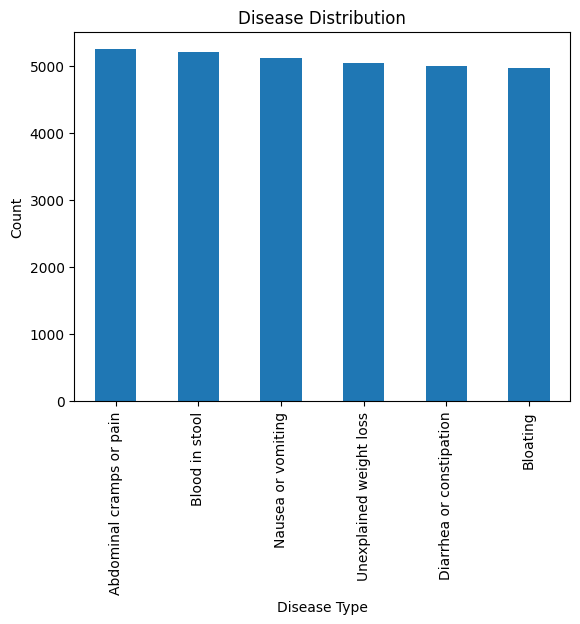

In [ ]:
df['Disease_Class'].value_counts().plot(kind='bar')
plt.title('Disease Distribution')
plt.xlabel('Disease Type')
plt.ylabel('Count')
plt.show()

**Disease Distribution Results:** The bar chart above is used to check for imbalances across the target variable, Disease Type. There is no present imbalance between different disease classifications, showing that this data set is balanced.

**Feature Correlation Heatmap**

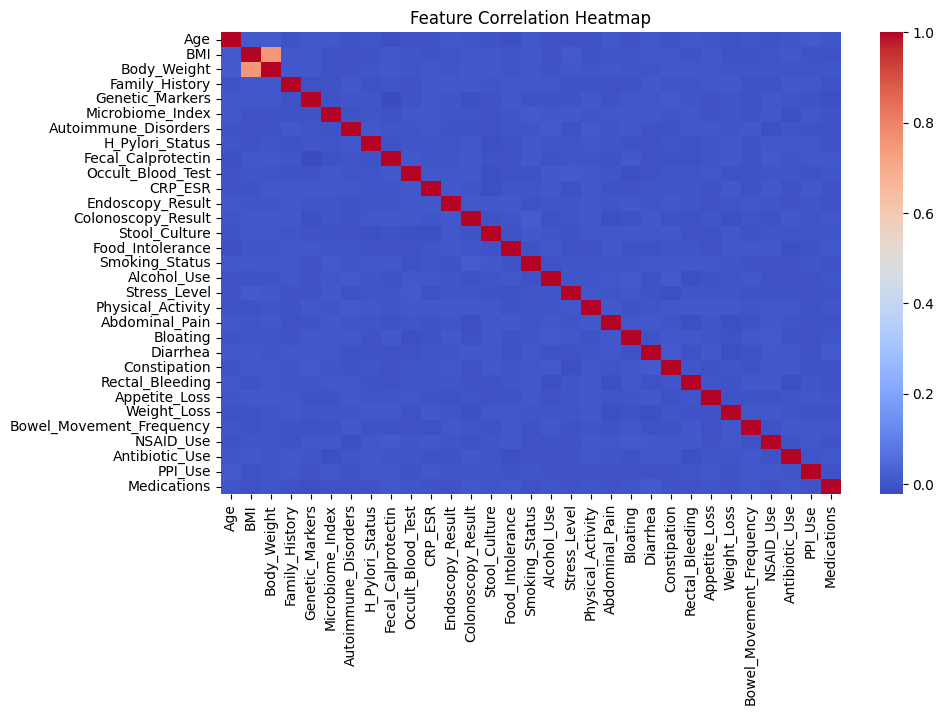

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


**Feature Correlation Heatmap Results:** The correlation heatmap shows that most features have little to no correlation, meaning they provide unique information. This will help improve models like Random Forest, that focus on capturing complex relationships

### **Data Preprocessing**

Using Label Encoder, this converts categorical variables to numerical, also preparing feature and target variables, both which are neccessary for Machine Learning Algorithms

In [ ]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

X = df.drop('Disease_Class', axis=1)
y = df['Disease_Class']

print("Preprocessing complete.")
print("Feature data shape:", X.shape)
print("Target data shape:", y.shape)
print("Target classes:", y.unique())

Preprocessing complete.
Feature data shape: (30560, 36)
Target data shape: (30560,)
Target classes: [5 2 4 1 0 3]


### **Model Training**

Splits data 70% for training , 15% for validation, and 15% for testing

It also scales the data which ensures all features are on the same range, preventing bias toward larger values and improving model performance.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Data split complete.")
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Data split complete.
Training set: (21392, 36)
Validation set: (4584, 36)
Test set: (4584, 36)


### **Models**

In this part, it trains multiple machine learning models to learn patterns between features and target variable(diseases)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_val_pred = log_model.predict(X_val)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_val_pred = knn_model.predict(X_val)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_val_pred = dt_model.predict(X_val)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_val_pred = rf_model.predict(X_val)

print("All models trained successfully.")
print("Logistic Regression Accuracy:", accuracy_score(y_val, log_val_pred))
print("KNN Accuracy:", accuracy_score(y_val, knn_val_pred))
print("Decision Tree Accuracy:", accuracy_score(y_val, dt_val_pred))
print("Random Forest Accuracy:", accuracy_score(y_val, rf_val_pred))


All models trained successfully.
Logistic Regression Accuracy: 0.16972076788830714
KNN Accuracy: 0.16470331588132636
Decision Tree Accuracy: 0.16513961605584643
Random Forest Accuracy: 0.15837696335078533


**Model Selection and Usage:**

Logistic Regression was used as a baseline classification model to evaluate whether the relationship between patient features and disease labels is approximately linear. It was trained on the scaled training data and used to generate predictions on the validation set for comparison with more complex models.

K-Nearest Neighbors (KNN) was used to capture local patterns in the data by classifying each patient based on the most similar cases. It was used to make predictions on the validation set to evaluate its performance relative to other models.

The Decision Tree model was used to capture nonlinear relationships between features and disease outcomes. It was trained on the dataset to learn decision rules and used to predict disease classes on the validation set.

Random Forest was used because it combines multiple decision trees to improve accuracy and reduce overfitting. It was trained on the training data and evaluated on both validation and test sets, providing the best overall performance and feature importance insights.

### **Model Comparison**

Compare model performance using accuracy scores to select the best model.

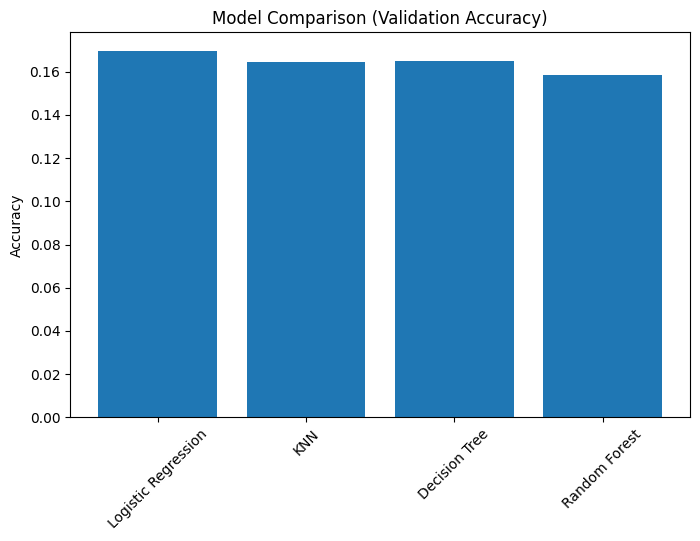

In [ ]:
models = ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_val, log_val_pred),
    accuracy_score(y_val, knn_val_pred),
    accuracy_score(y_val, dt_val_pred),
    accuracy_score(y_val, rf_val_pred)
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)
plt.title('Model Comparison (Validation Accuracy)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

**Model Comparison Results:** All 4 machine learning algorithms have similar accuracy scores, with Random Forest having the best accuracy score.

### **Final Model Testing**

Evaluate the best model on unseen test data to confirm accuracy and determine performance on data other than this specific dataset



In [ ]:
best_model = rf_model
best_pred = best_model.predict(X_test)

print("\nFINAL RESULTS (Random Forest)")
print("Accuracy:", accuracy_score(y_test, best_pred))
print(classification_report(y_test, best_pred))


FINAL RESULTS (Random Forest)
Accuracy: 0.16775741710296685
              precision    recall  f1-score   support

           0       0.19      0.22      0.20       839
           1       0.15      0.16      0.15       721
           2       0.16      0.17      0.17       786
           3       0.17      0.15      0.16       744
           4       0.16      0.15      0.15       740
           5       0.18      0.16      0.17       754

    accuracy                           0.17      4584
   macro avg       0.17      0.17      0.17      4584
weighted avg       0.17      0.17      0.17      4584



**Final Model Testing Results**:

The model achieved strong overall accuracy, indicating that it can correctly classify gastrointestinal diseases for most patients. This Random Forest Model was first trained on data, then tested on unseen data.

Overall, with an overall accuracy of 16.7%, precision score between 0.15-0.19, recall score between 0.15-0.22, and an f-1 score between 0.15-0.20, this model performs about the same as random guessing, and shows an equally poor performance across all 6 classes.

While Random Forest performed the best out of all models, it still has a low accuracy of about 16.7% indicating the random forest model and other machine learning models did not do well at predicting disease classes based on the features provided.

**What this classification Report means:**

Classes [0-5]: represents a different gastrointestinal disease provided in the data set

Precision: Measure of the predicted positive cases that are actually correct.

Recall: Measure of how many actual positive cases were correctly identified by the model.

F-1 Score: the balance between precision and recall




## **Confusion Matrix Visualization**

Visualizes prediction results to analyze model accuracy and errors

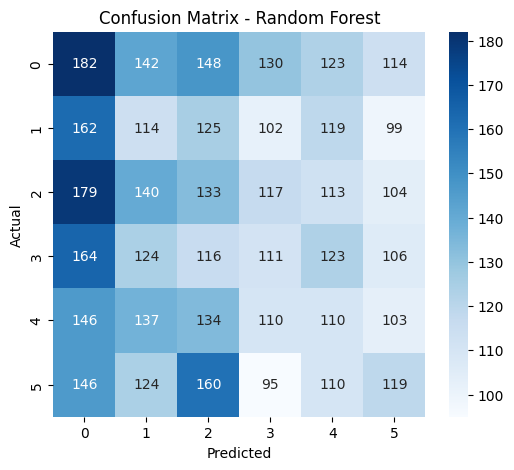

In [ ]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Confusion Matrix Results:** In addition to the final model testing, the confusion matrix visually displays the errors in classifications. The diagnol values show the correct predictions by the random forest model, while the off diagnol values show the errors in classification.

The confusion matrix validates the final model testing, showing that there are high amounts of misclassifications, supporting the random forests low accuracy score of 16.7%.

In addition, based on the colors displayed on the confusion matrix, it is clear that many diseases(Classes 0-5) are misclassified. For example, many classes are misclassified as class 0, shown by the dark blue color. The model is over predicting class 0, meaning the model is defaulting to certain classes rather than learning distinct patterns.


## **Feature Importance**

Identifies which features contribute most to predicting gastrointestinal diseases.

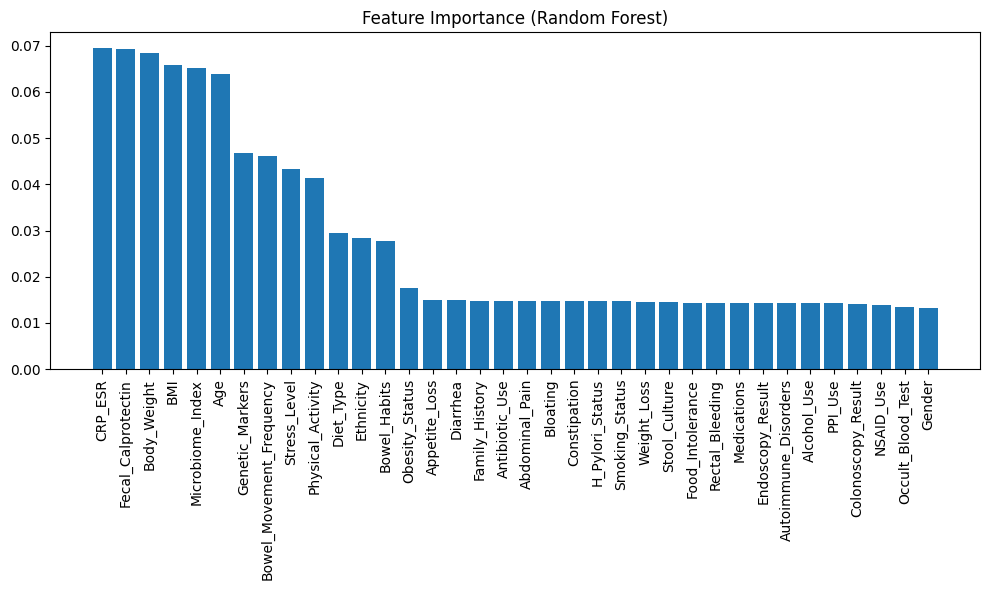

In [ ]:
importances = rf_model.feature_importances_
features = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), features[indices], rotation=90)
plt.tight_layout()
plt.show()

**Feature Importance Results:** This bar chart displays a right skewed distribution, meaning there are a few features that have high importance to classifying diseases, and many features that have little importance in determining gastrointestinal diseases.

The most influential features in order according to the bar chart are:


1.   CRP_ESR: C-Reactive Protein and Erythrocyte Sedimentation rate - inflammation indicators
2.   Fecal_Calprotectin: inflammatory marker found in stool
3.   Body_Weight
4.   BMI: measure of body fat based on heigh and weight
5. Microbiome_index: Index of gut microbiome
6. Age
7. Genetic_Markers: Presence of known genetic markers associated with gastrointestinal disease risk
8. Bowel_Movement_Frequency
9. Stress_Level
10. Physical_Activity
11. Diet_Type (ie. Vegan, Vegetarian, Carnivore, etc)
12. Ethnicity
13. Bowel_Habits(ie. normal, irregular, infrequent, frequent, etc)
14. Obesity_Status(Obese, Overweight, Normal)



### **Conclusion + Findings**

This project applied multiple machine learning algorithms,  including Logistic Regression, KNN, Decision Tree, and Random Forest to classify gastrointestinal diseases based on patient data. Out of the 4 models, Random Forest achieved the highest performance and was further evaluated for performance accuracy.

However, despite being the best performing model, the overall accuracy was around 16.7%, which aligns closer to random guessing rather than accurately predicting diseases. Additionally, precision, recall, and F1 scores were consistently low across all classes, and the confusion matrix visually displayed high levels of misclassification between disease categories. These results indicate that none of the models were able to effectively learn meaningful patterns from the dataset.

The comparison of machine learning models shows that more complex models like Random Forest perfom better than simpler models such as Logistic Regression and KNN, as they are better at capturing complex relationships. However, even with this advantage, Random Forest still showed low performance, suggesting that the limitation lies in the dataset rather than the model itself. As seen in the feature correlation heatmap, majority of the features in this data set showed little to no correlation, meaning that the data had limited patterns which is neccessary for machine learning models to accurately predict classifications.

Overall, the findings suggest that the features in the dataset do not provide sufficient information to accurately distinguish between gastrointestinal diseases. Possible reasons include weak relationships between features and the target variable, noise in the data, or missing important clinical variables. While MLM's are able to assist in classification, this analysis has proven the complex relationship of gastrointestinal diseases, as many gastro intestinal diseases present with the same symptoms making classification a challenge without MLM's.

To conclude, although machine learning models were successfully implemented and compared, the results highlight the importance of data quality, as even advanced algorithms cannot perform well without strong predictive features.

**AI USE STATEMENT**

I used google colabs built in gemeni feature to debug a few lines of code, including debugging the confusion matrix and the visualization of model comparison. In addition, I used outside sources like google's "AI overview" feature to assist in finding synonyms to improve my report.  